In [8]:
#import random
import torch as tc
import numpy as np
import qutip as qt
import pandas as pd
import function as my
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline

from tqdm import tqdm

S(x) = somatorio a_n*B_n(x)

In [9]:
def open_uniform_knots(t0, t1, n_basis, k):
    n_internal = n_basis - k - 1
    if n_internal > 0:
        internal = np.linspace(t0, t1, n_internal + 2)[1:-1]
    else:
        internal = np.array([])
    knots = np.r_[np.full(k+1, t0), internal, np.full(k+1, t1)]
    return knots

def bspline_design_matrix(t_eval, knots, k):
    n_basis = len(knots) - k - 1
    B = np.zeros((len(t_eval), n_basis), dtype=np.float64)

    for j in range(n_basis):
        c = np.zeros(n_basis)
        c[j] = 1.0
        spl = BSpline(knots, c, k, extrapolate=True)
        B[:, j] = spl(t_eval)

    return B

class SIN(tc.nn.Module):
    def __init__(self): 
        super(SIN, self).__init__() 
    def forward(self, x):
        return tc.sin(x)
    
O_op =[ qt.sigmax(),
         qt.sigmay(),
         qt.sigmaz()
                ]

def Field(t):
    return ( 1.5* np.sin(2.0 * t) - 0.3*np.cos(3* t - 0.5) + 0.4*np.sin(7.0 * t)
        )*np.sin(np.pi*t/tfinal)**2

def data_qubit(O_op,tlist,field,device="cpu"):
    # Lista de tempos para a evolução
    H0 = 0.5*qt.sigmaz()
    H1 = 0.5*qt.sigmax()
    H  = [H0,[H1,field(tlist)]]
    
    # Hamiltonian Lindbladian
    c_ops = []
    
    # Estado inicial (cada qubit na superposição de |0> e |1>)
    # |+> = (|0> + |1>)/sqrt(2)
    theta1  = np.pi/4
    phi1    = 0.0 #np.pi/3
    ket_plus1 = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))
    psi0 = ket_plus1
    
    # Solução da equação de Schrödinger
    options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
    result  = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=O_op,options=options)

    expect  = tc.tensor( np.array( result.expect),device = device).transpose(0, 1)
    return expect

class BSplineField(tc.nn.Module):
    def __init__(self, t_eval, t0, t1, n_basis=10, k=3, init_fun=None):
        super().__init__()

        knots = open_uniform_knots(t0, t1, n_basis, k)
        B = bspline_design_matrix(np.asarray(t_eval, dtype=np.float64), knots, k)

        self.register_buffer("B", tc.tensor(B, dtype=tc.float32))
        self.register_buffer("knots", tc.tensor(knots, dtype=tc.float32))
        self.k = k

        coeff0 = np.zeros(n_basis, dtype=np.float32)

        # opcional: inicializar os coeficientes perto de uma função conhecida
        if init_fun is not None:
            y0 = init_fun(np.asarray(t_eval, dtype=np.float64))
            coeff0, *_ = np.linalg.lstsq(B, y0, rcond=None)

        self.coeffs = tc.nn.Parameter(
            tc.tensor(coeff0.reshape(-1, 1), dtype=tc.float32)
        )

    def forward(self, time):
        # aqui assumimos que o grid de treino é o mesmo usado para construir B
        return self.B @ self.coeffs

    def smoothness_penalty(self):
        c = self.coeffs[:, 0]
        return ((c[2:] - 2*c[1:-1] + c[:-2])**2).mean()

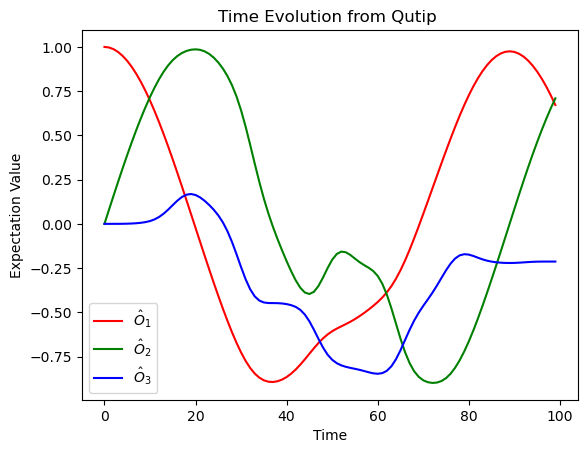

In [10]:
tfinal      = 2.52*np.pi
N           = 100
Nedo        = 3
Nfield      = 1

tlist = np.linspace(0.0, tfinal, N)
valor_esperado_data  = data_qubit(O_op,tlist,Field,device="cpu")

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$", color=colors[i])
    
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from Qutip ')
plt.show()

In [11]:
time = tc.linspace(
    0, tfinal, N,
    dtype = tc.float32,
    requires_grad = True).reshape((-1, 1))

time_np = time.detach().cpu().numpy().ravel()

X_vector = my.Rede(
    neuronio   = [15,15],
    input_     = 1,
    output_    = 3,
    activation =[SIN(), SIN()]
)

JX_spline = BSplineField(
    t_eval = time_np,
    t0  = 0.0,
    t1  = tfinal,
    n_basis = 30,
    k   = 10,
)

opt = tc.optim.Adam(
    list(X_vector.parameters()) + list(JX_spline.parameters()),
    lr=0.001,weight_decay=1e-5
)

100%|██████████| 100000/100000 [01:48<00:00, 922.41it/s]


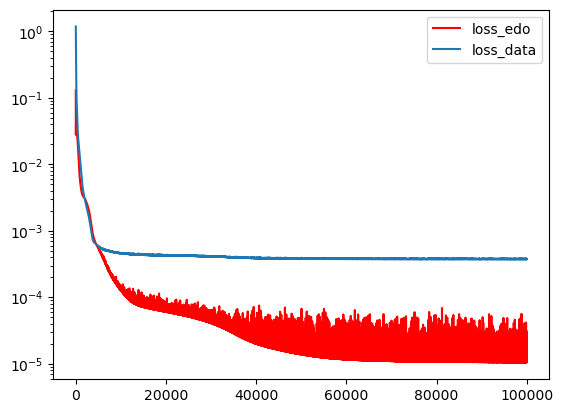

In [12]:
JZ = 1e0
JY = 0e0
epocas  = 100000

LOSS    = []
LOSS1   = []
LOSS2   = []
hisorty_of_param = []
for _ in tqdm(range(epocas)):
    ####### Forward pass #######
    y   = X_vector(time)    # [N,3]
    JX  = JX_spline(time)   # [N,1]

    ######## Loss edo #######
    dX_dt = []
    for i in range(y.shape[1]):
        dX_dt.append(
            tc.autograd.grad(
                outputs = y[:, i],
                inputs = time,
                grad_outputs = tc.ones_like(y[:, i]),
                #retain_graph = True,
                create_graph = True)[0])
    dX_dt   = tc.cat(dX_dt, dim=1)
    
    X,Y,Z = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    LOSS_edo  = 0
    
    LOSS_edo += (dX_dt[:,0:1] - (-1.0*Y))**2
    LOSS_edo += (dX_dt[:,1:2] - ( 1.0*X - 1.0*JX*Z))**2
    LOSS_edo += (dX_dt[:,2:3] - ( 1.0*JX*Y))**2
    LOSS_edo = LOSS_edo.mean()


    ####### loss data(expected values) #######
    LOSS_data=0    
    LOSS_data +=(y[:,0:1]  - valor_esperado_data[:,0:1])**2 
    LOSS_data +=(y[:,1:2]  - valor_esperado_data[:,1:2])**2 
    LOSS_data +=(y[:,2:3]  - valor_esperado_data[:,2:3])**2 
    LOSS_data = LOSS_data.mean()
    
    # suavidade da spline
    LOSS_smooth = 1e-4 * JX_spline.smoothness_penalty()

    ####### Loss total #######
    loss_i = LOSS_edo + LOSS_data + LOSS_smooth

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()
    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="loss_data")
plt.yscale("log")
plt.legend()
plt.show()

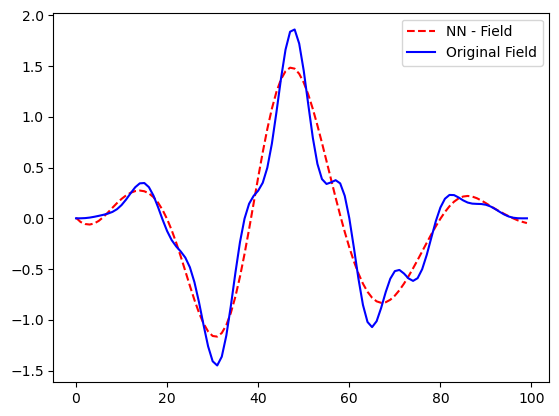

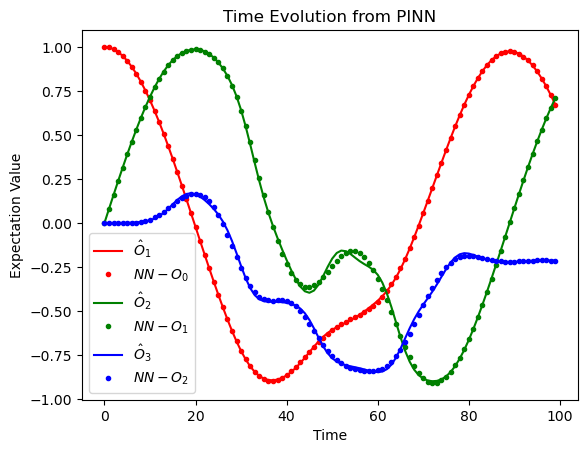

In [13]:
t_points = np.linspace(0,tfinal, N)
JX = JX_spline(time).detach().numpy()

field_original=Field(t_points)
plt.plot(JX,"r--",label="NN - Field")
plt.plot(field_original,"b-",label="Original Field")
plt.legend()
plt.show()

X_vector.eval()
X_  = X_vector(time).detach().numpy()

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$", color=colors[i])
    plt.plot(X_[:,i],"." ,label=fr"$NN - O_{{{i}}}$", color=colors[i])
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from PINN')
plt.show()


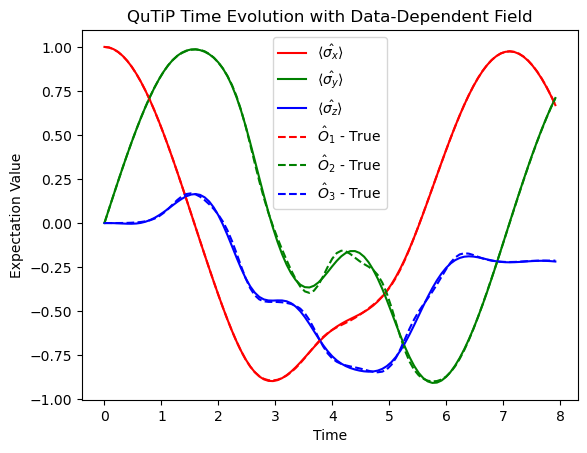

In [14]:
H0 = .5*qt.sigmaz()
H1 = .5*qt.sigmax()
# The full Hamiltonian is defined as a list: 
# H = H0 + f(t) * H1, where f(t) is the field data
H = [H0, [H1, JX.flatten()]] # QuTiP uses cubic spline interpolation for field_data

# (Optional) Define collapse operators for an open system simulation
c_ops = [] # e.g., c_ops = [np.sqrt(gamma) * qt.sigmam()]

# 3. Define the initial state and expectation value operators
theta1  = np.pi/4
phi1    = 0.0 #np.pi/3
psi0    = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))

O_op =[ qt.sigmax(),
         qt.sigmay(),
         qt.sigmaz()
                ]

# 4. Simulate the time evolution
options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
result  = qt.mesolve(H, psi0, t_points, c_ops=c_ops, e_ops=O_op,options=options)

# 5. Plot the results
plt.figure()
plt.plot(t_points, result.expect[0],"r-", label=r'$\langle \hat{\sigma_x}\rangle$',)
plt.plot(t_points, result.expect[1],"g-", label=r'$\langle \hat{\sigma_y}\rangle$')
plt.plot(t_points, result.expect[2],"b-", label=r'$\langle \hat{\sigma_z}\rangle$')

plt.plot(t_points,valor_esperado_data[:,0].cpu() ,label=fr"$\hat{{O}}_{{1}}$ - True", color='r', linestyle='--')
plt.plot(t_points,valor_esperado_data[:,1].cpu() ,label=fr"$\hat{{O}}_{{2}}$ - True", color='g', linestyle='--')
plt.plot(t_points,valor_esperado_data[:,2].cpu() ,label=fr"$\hat{{O}}_{{3}}$ - True", color='b', linestyle='--')


plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('QuTiP Time Evolution with Data-Dependent Field')
plt.show()